# Task 3-2: CNNs on Fashion MNIST



In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [ ]:
transform_base = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_ds_base = datasets.FashionMNIST(root="./data", train=True, transform=transform_base, download=True)
test_ds = datasets.FashionMNIST(root="./data", train=False, transform=transform_base, download=True)

train_ds_aug = datasets.FashionMNIST(root="./data", train=True, transform=transform_aug, download=True)

BATCH_SIZE = 64
train_loader_base = DataLoader(train_ds_base, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)



test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
class CNNBaseline(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(64 * 3 * 3, 64), nn.ReLU(), nn.Linear(64, num_classes))

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class CNNDropout(nn.Module):
    def __init__(self, num_classes=10, drop=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(drop),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(drop),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(64 * 3 * 3, 64), nn.ReLU(), nn.Dropout(drop), nn.Linear(64, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))


class CNNBatchNorm(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(64 * 3 * 3, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Linear(64, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))


class CNNDropoutBN(nn.Module):
    def __init__(self, num_classes=10, drop=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(drop),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(drop),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(64 * 3 * 3, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(drop), nn.Linear(64, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))

In [ ]:
def train_eval_cnn(model, train_loader, test_loader, epochs=5, lr=1e-3, name="CNN"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "test_loss": [], "test_acc": []}
    best_epoch, best_acc = 0, 0.0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        epoch_train = train_loss / len(train_loader)
        history["train_loss"].append(epoch_train)

        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                logits = model(images)
                total_loss += criterion(logits, labels).item() * images.size(0)
                correct += (logits.argmax(1) == labels).sum().item()
                total += images.size(0)
        test_loss = total_loss / total
        acc = 100.0 * correct / total
        history["test_loss"].append(test_loss)
        history["test_acc"].append(acc)
        print(f"{name} - epoch {epoch+1}/{epochs}: train loss={epoch_train:.4f}, test loss={test_loss:.4f}, acc={acc:.2f}%")
        if acc > best_acc:
            best_acc = acc
            best_epoch = epoch

    history["best_epoch"] = best_epoch
    history["best_acc"] = best_acc
    return history["test_loss"][-1], history["test_acc"][-1], history

In [14]:
EPOCHS = 20
results = []
histories = []  # per-config history for plotting

# 1. Baseline CNN, no augmentation
torch.manual_seed(42)
m = CNNBaseline()
loss, acc, hist = train_eval_cnn(m, train_loader_base, test_loader, epochs=EPOCHS)
results.append({"Config": "Baseline CNN", "Loss": loss, "Accuracy %": acc, "Best epoch": hist["best_epoch"]})
histories.append(("Baseline CNN", hist))
print(f"Baseline CNN: best test accuracy {hist['best_acc']:.2f}% at epoch {hist['best_epoch']} (converged around epoch {hist['best_epoch']})")

# 2. CNN + Dropout, no augmentation
torch.manual_seed(42)
m = CNNDropout(drop=0.25)
loss, acc, hist = train_eval_cnn(m, train_loader_base, test_loader, epochs=EPOCHS, name="CNN + Dropout")
results.append({"Config": "CNN + Dropout", "Loss": loss, "Accuracy %": acc, "Best epoch": hist["best_epoch"]})
histories.append(("CNN + Dropout", hist))
print(f"CNN + Dropout: best test accuracy {hist['best_acc']:.2f}% at epoch {hist['best_epoch']} (converged around epoch {hist['best_epoch']})")

# 3. CNN + BatchNorm, no augmentation
torch.manual_seed(42)
m = CNNBatchNorm()
loss, acc, hist = train_eval_cnn(m, train_loader_base, test_loader, epochs=EPOCHS)
results.append({"Config": "CNN + BatchNorm", "Loss": loss, "Accuracy %": acc, "Best epoch": hist["best_epoch"]})
histories.append(("CNN + BatchNorm", hist))
print(f"CNN + BatchNorm: best test accuracy {hist['best_acc']:.2f}% at epoch {hist['best_epoch']} (converged around epoch {hist['best_epoch']})")

# 4. CNN + Dropout + BatchNorm, no augmentation
torch.manual_seed(42)
m = CNNDropoutBN(drop=0.25)
loss, acc, hist = train_eval_cnn(m, train_loader_base, test_loader, epochs=EPOCHS, name="CNN + Dropout + BN")
results.append({"Config": "CNN + Dropout + BN", "Loss": loss, "Accuracy %": acc, "Best epoch": hist["best_epoch"]})
histories.append(("CNN + Dropout + BN", hist))
print(f"CNN + Dropout + BN: best test accuracy {hist['best_acc']:.2f}% at epoch {hist['best_epoch']} (converged around epoch {hist['best_epoch']})")

# 5. Baseline CNN with data augmentation
torch.manual_seed(42)
m = CNNBaseline()
loss, acc, hist = train_eval_cnn(m, train_loader_aug, test_loader, epochs=EPOCHS, name="Baseline + Data Aug")
results.append({"Config": "Baseline + Data Aug", "Loss": loss, "Accuracy %": acc, "Best epoch": hist["best_epoch"]})
histories.append(("Baseline + Data Aug", hist))
print(f"Baseline + Data Aug: best test accuracy {hist['best_acc']:.2f}% at epoch {hist['best_epoch']} (converged around epoch {hist['best_epoch']})")

# 6. CNN + Dropout + BN with data augmentation
torch.manual_seed(42)
m = CNNDropoutBN(drop=0.25)
loss, acc, hist = train_eval_cnn(m, train_loader_aug, test_loader, epochs=EPOCHS, name="Dropout+BN + Data Aug")
results.append({"Config": "Dropout+BN + Data Aug", "Loss": loss, "Accuracy %": acc, "Best epoch": hist["best_epoch"]})
histories.append(("Dropout+BN + Data Aug", hist))
print(f"Dropout+BN + Data Aug: best test accuracy {hist['best_acc']:.2f}% at epoch {hist['best_epoch']} (converged around epoch {hist['best_epoch']})")

CNN - epoch 1/20: train loss=0.5246, test loss=0.3821, acc=86.02%
CNN - epoch 2/20: train loss=0.3140, test loss=0.2997, acc=89.24%
CNN - epoch 3/20: train loss=0.2663, test loss=0.3213, acc=88.15%
CNN - epoch 4/20: train loss=0.2412, test loss=0.2854, acc=89.75%
CNN - epoch 5/20: train loss=0.2181, test loss=0.2639, acc=90.66%
CNN - epoch 6/20: train loss=0.2002, test loss=0.2569, acc=90.66%
CNN - epoch 7/20: train loss=0.1856, test loss=0.2588, acc=90.91%
CNN - epoch 8/20: train loss=0.1703, test loss=0.2480, acc=91.15%
CNN - epoch 9/20: train loss=0.1582, test loss=0.2383, acc=91.45%
CNN - epoch 10/20: train loss=0.1437, test loss=0.2560, acc=91.32%
CNN - epoch 11/20: train loss=0.1326, test loss=0.2562, acc=91.61%
CNN - epoch 12/20: train loss=0.1246, test loss=0.2518, acc=92.21%
CNN - epoch 13/20: train loss=0.1133, test loss=0.2677, acc=91.12%
CNN - epoch 14/20: train loss=0.1030, test loss=0.2825, acc=91.53%
CNN - epoch 15/20: train loss=0.0939, test loss=0.2721, acc=91.84%
CNN 

In [15]:
# Comparison table: loss and accuracy
df_cnn = pd.DataFrame(results)
df_cnn

,Config,Loss,Accuracy %,Best epoch
0,Baseline CNN,0.349759,91.86,11
1,CNN + Dropout,0.230278,92.09,19
2,CNN + BatchNorm,0.361293,92.00,11
3,CNN + Dropout + BN,0.211785,92.96,19
4,Baseline + Data Aug,0.228237,91.98,17
5,Dropout+BN + Data Aug,0.223034,91.76,19


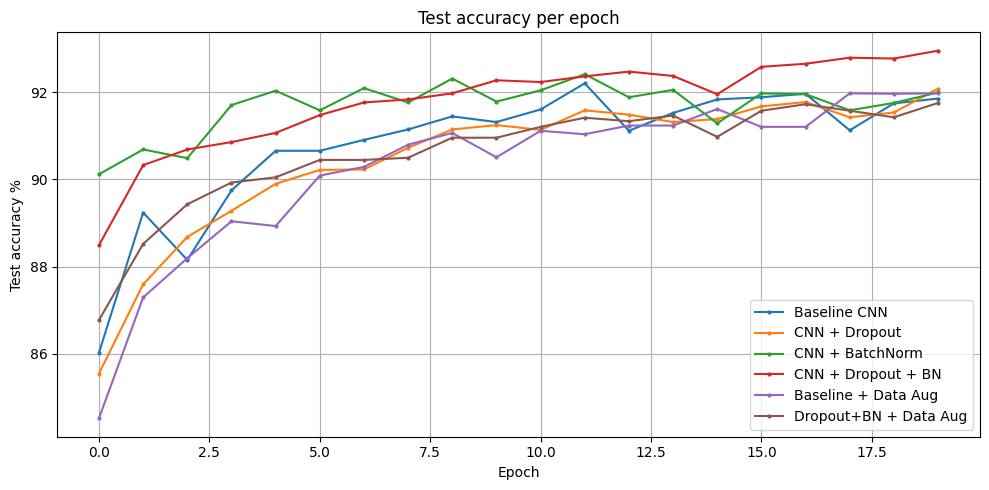

In [18]:
plt.figure(figsize=(10, 5))
for name, hist in histories:
    plt.plot(range(len(hist["test_acc"])), hist["test_acc"], label=name, marker=".", markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Test accuracy %")
plt.title("Test accuracy per epoch")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

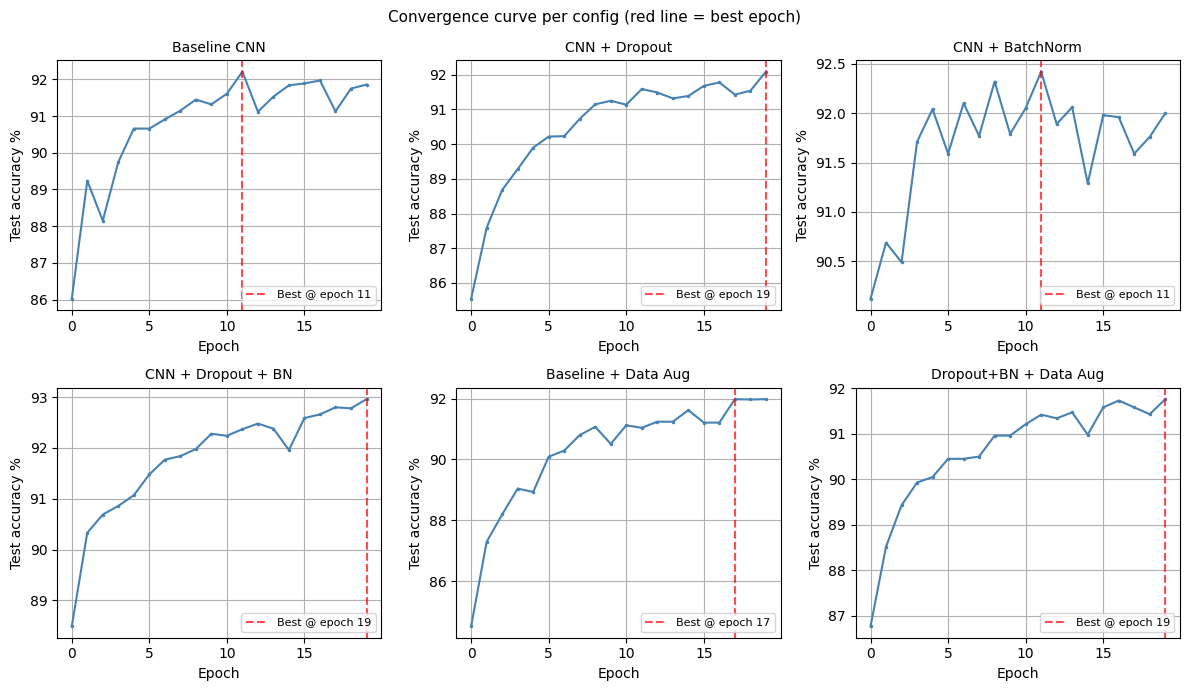

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()
for i, (name, hist) in enumerate(histories):
    ax = axes[i]
    epochs = range(len(hist["test_acc"]))
    ax.plot(epochs, hist["test_acc"], color="steelblue", marker=".", markersize=3)
    ax.axvline(hist["best_epoch"], color="red", linestyle="--", alpha=0.7, label=f"Best @ epoch {hist['best_epoch']}")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Test accuracy %")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True)
plt.suptitle("Convergence curve per config (red line = best epoch)", fontsize=11)
plt.tight_layout()
plt.show()